# Залежності

`pip install torchvision`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import torch 
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms 
from torchvision.utils import make_grid

In [2]:
print(torch.__version__)
print(torchvision.__version__)

2.12.1+cpu
0.27.1+cpu


In [3]:
SEED = 42
torch.manual_seed(SEED)

# MNIST Dataset

* mean = 0.1307
* std = 0.3081

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])


train_dataset = datasets.MNIST(
    root='data/',
    download=True,
    train=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root='data/',
    download=True,
    train=False,
    transform=transform
)

In [5]:
print("train dataset len: ", len(train_dataset))
print("test dataset len: ", len(test_dataset))

train dataset len:  60000
test dataset len:  10000


In [6]:
print(train_dataset)

Dataset MNIST
    Number of datapoints: 60000
    Root location: data/
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.1307,), std=(0.3081,))
           )


In [7]:
train_dataloader = DataLoader(
    dataset=train_dataset,
    shuffle=True,
    batch_size=64
)

test_dataloader = DataLoader(
    dataset=test_dataset,
    shuffle=False,
    batch_size=64
)

In [8]:
images, labels = next(iter(test_dataloader))
print("images shape: ", images.shape)
print("labels shape: ", labels.shape)
print("first 10 labels: ", labels[:10])

images shape:  torch.Size([64, 1, 28, 28])
labels shape:  torch.Size([64])
first 10 labels:  tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9])


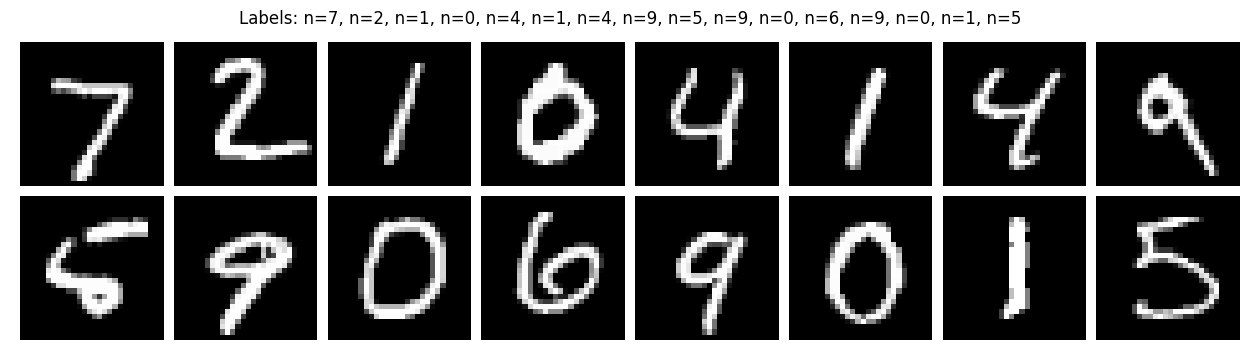

In [9]:
def show_mnist_sample(images, labels, n=16):
    grid = make_grid(images[:n], nrow=8, normalize=True, pad_value=1)
    
    plt.figure(figsize=(16, 6))
    plt.imshow(grid.permute(1, 2, 0))
    
    title = ", ".join([f"n={n}" for n in map(str, labels[:n].tolist())])
    
    plt.title("Labels: " + title)
    plt.axis("off")
    
    plt.show()
    
    
show_mnist_sample(images, labels, 16)

# Base CNN

In [10]:
model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
    
    nn.ReLU(),
    nn.MaxPool2d(2),
    
    nn.Flatten(),
    nn.Linear(16 * 14 * 14, 10)
).to(device="cpu")
# функція помилок
loss_fn = nn.CrossEntropyLoss()
# оптимізатор
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Функції для навчання та оцінки

In [11]:
def train_one_epoch(model, dataloader, loss_fn, optimizer):
    model.train()
    
    total_loss = 0.0
    totas_items = 0
    total_correct = 0
    
    for images, labels in dataloader:
        # обнуляємо градієнти, щоб модель правильно началась
        optimizer.zero_grad(set_to_none=True)
        
        # forward pass - проходимо вперед
        logits = model(images)
    
        # рахуємо помилку
        loss = loss_fn(logits, labels)
        
        # backpropagation - рахуємо градієнти
        loss.backward()
        
        # оновлює ваги моделі, використовує пораховані градієнти
        optimizer.step()
        
        total_loss += loss.item() * len(labels)
        totas_items += len(labels)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        
    return {
        "loss": total_loss / totas_items,
        "accuracy": total_correct / totas_items
    }    

In [12]:
@torch.no_grad()
def evaluate(model, dataloader, loss_fn):
    model.eval()
    
    total_loss = 0.0
    total_items = 0
    total_correct = 0
    
    for images, labels in dataloader:
        # forward pass - проходимо вперед
        logits = model(images)
        
        # рахуємо помилку
        loss = loss_fn(logits, labels)
        
        total_loss += loss.item() * labels.size(0)
        total_items += labels.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        
    return {
        "loss": total_loss / total_items,
        "accuracy": total_correct / total_items
    }

In [13]:
def model_fit(model, train_dataloader, test_dataloader, loss_fn, optimizer, epochs=10):
    history = []    
    
    for epoch in range(1, epochs + 1):
        train_metrics = train_one_epoch(model, train_dataloader, loss_fn, optimizer)
        test_metrics = evaluate(model, test_dataloader, loss_fn)
    
        row = {
            "epoch": epoch,
            "train_loss": train_metrics['loss'],
            "train_accuracy": train_metrics['accuracy'],
            "test_loss": test_metrics['loss'],
            "test_accuracy": test_metrics['accuracy']
        }
        history.append(row)
        print(row)
        
    return pd.DataFrame(history)

In [14]:
baseline_history = model_fit(model, train_dataloader, test_dataloader, loss_fn, optimizer)
baseline_history

{'epoch': 1, 'train_loss': 0.2154375205596288, 'train_accuracy': 0.9376333333333333, 'test_loss': 0.10331923898160457, 'test_accuracy': 0.9683}
{'epoch': 2, 'train_loss': 0.08616650826235613, 'train_accuracy': 0.9745333333333334, 'test_loss': 0.07124259326085448, 'test_accuracy': 0.9783}
{'epoch': 3, 'train_loss': 0.06589107698723674, 'train_accuracy': 0.9804, 'test_loss': 0.06850124376937747, 'test_accuracy': 0.9771}
{'epoch': 4, 'train_loss': 0.05679518765409788, 'train_accuracy': 0.9825333333333334, 'test_loss': 0.05961949348654598, 'test_accuracy': 0.9804}
{'epoch': 5, 'train_loss': 0.0500151086072127, 'train_accuracy': 0.98485, 'test_loss': 0.05941252038814127, 'test_accuracy': 0.9811}
{'epoch': 6, 'train_loss': 0.043453918130199116, 'train_accuracy': 0.98665, 'test_loss': 0.058269093037676065, 'test_accuracy': 0.9807}
{'epoch': 7, 'train_loss': 0.03969701655007278, 'train_accuracy': 0.9874833333333334, 'test_loss': 0.06548062903159298, 'test_accuracy': 0.9782}
{'epoch': 8, 'train

,epoch,train_loss,train_accuracy,test_loss,test_accuracy
0,1,0.215438,0.937633,0.103319,0.9683
1,2,0.086167,0.974533,0.071243,0.9783
2,3,0.065891,0.980400,0.068501,0.9771
3,4,0.056795,0.982533,0.059619,0.9804
4,5,0.050015,0.984850,0.059413,0.9811
5,6,0.043454,0.986650,0.058269,0.9807
6,7,0.039697,0.987483,0.065481,0.9782
7,8,0.035573,0.988933,0.060999,0.9815
8,9,0.031170,0.990083,0.060090,0.9821
9,10,0.027919,0.991383,0.063747,0.9811


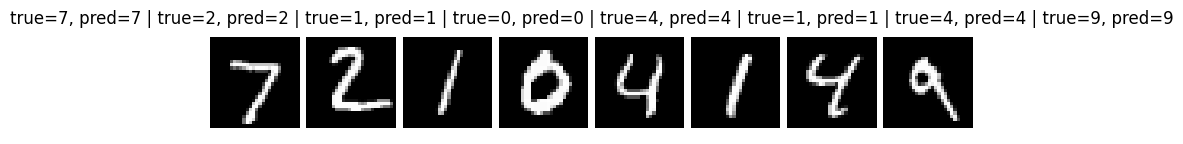

In [17]:
@torch.no_grad()
def show_predictions(model, dataloader, n=16):
    model.eval()
    images, labels = next(iter(dataloader))
    
    logits = model(images)
    y_pred = logits.argmax(dim=1)
    
    plt.figure(figsize=(10, 4))
    grid = make_grid(images[:n], nrow=8, normalize=True, pad_value=1)
    plt.imshow(grid.permute(1, 2, 0))
    
    title = " | ".join([f"true={t}, pred={p}" for t, p in zip(labels[:n], y_pred[:n])])
    
    plt.title(title)
    plt.axis("off")
    plt.show()
    
show_predictions(model, test_dataloader, 8)

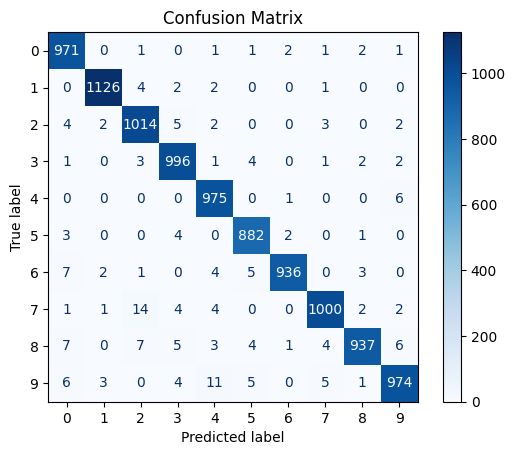

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


all_true = torch.tensor([])
all_pred = torch.tensor([])

for images, labels in test_dataloader:
    logits = model(images)
    y_pred = logits.argmax(dim=1)
    all_true = torch.cat((all_true, labels), dim=0)
    all_pred = torch.cat((all_pred, y_pred), dim=0)
    
cm = confusion_matrix(all_true, all_pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()